# <span style="color:red"> **LSN - Esercitazione 06**
### <span style="color:green"> 10.04.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:

#### Esercizio 06.1
- commentare cosa accade all'accettazione quando siamo ad alte e basse temperature e, di conseguenza, come è opportuno muoversi
- è corretta l'implementazione della suscettività? devo moltiplicare per beta e dividere per npart dentro average e non dentro measure?


## <span style="color:blue">**Esercizio 06.1**

**1) Energia interna $U(N,T) = \langle H \rangle_{h=0}$**

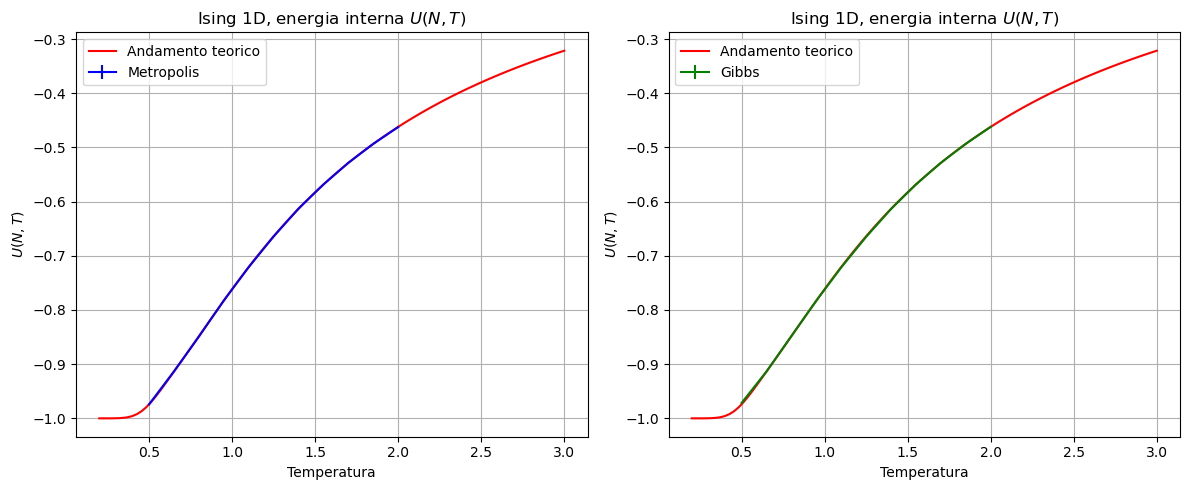

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data_U_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/total_energy.dat")
data_U_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/total_energy.dat")

temperature = data_U_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

U_m = data_U_m[:,3] # carico i valori medi 
error_U_m = data_U_m[:,4]
U_g = data_U_g[:,3] # carico i valori medi 
error_U_g = data_U_g[:,4]

#linea teorica
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, U_m, yerr=error_U_m, color = 'b', label='Metropolis')
axes[0].plot(T, e, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$U(N,T)$")
axes[0].set_title("Ising 1D, energia interna $U(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, U_g, yerr=error_U_g, color = 'g', label='Gibbs')
axes[1].plot(T, e, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$U(N,T)$")
axes[1].set_title("Ising 1D, energia interna $U(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()



**2) Capacità termica $ C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$**

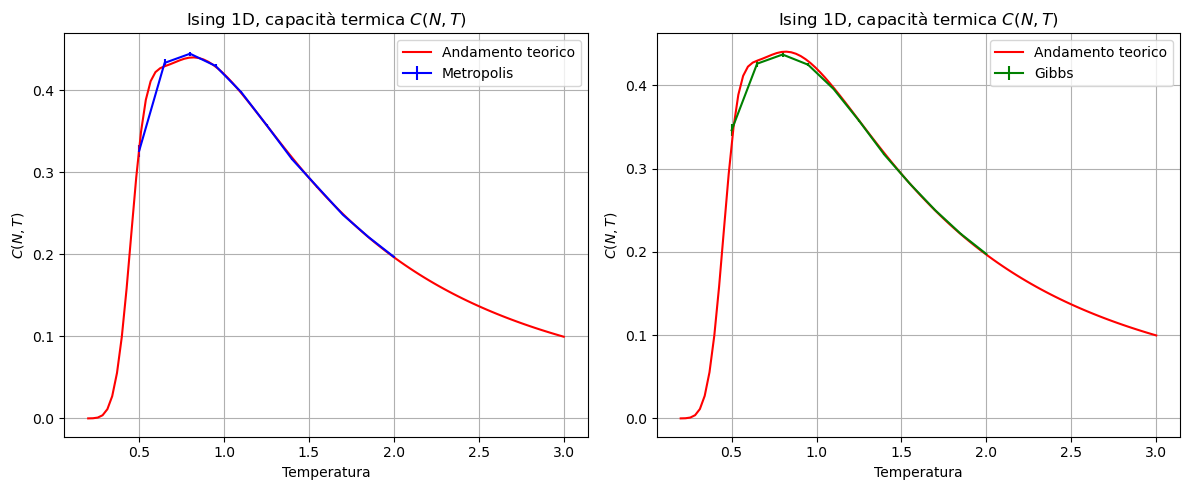

In [28]:
import numpy as np
import matplotlib.pyplot as plt

data_C_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/specific_heat.dat")
data_C_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/specific_heat.dat")

temperature = data_C_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

C_m = data_C_m[:,3] # carico i valori medi 
error_C_m = data_C_m[:,4]
C_g = data_C_g[:,3] # carico i valori medi 
error_C_g = data_C_g[:,4]

#linea teorica
heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, C_m, yerr=error_C_m, color = 'b', label='Metropolis')
axes[0].plot(T, heat, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$C(N,T)$")
axes[0].set_title("Ising 1D, capacità termica $C(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, C_g, yerr=error_C_g, color = 'g', label='Gibbs')
axes[1].plot(T, heat, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$C(N,T)$")
axes[1].set_title("Ising 1D, capacità termica $C(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()



**3) Suscettività $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$**

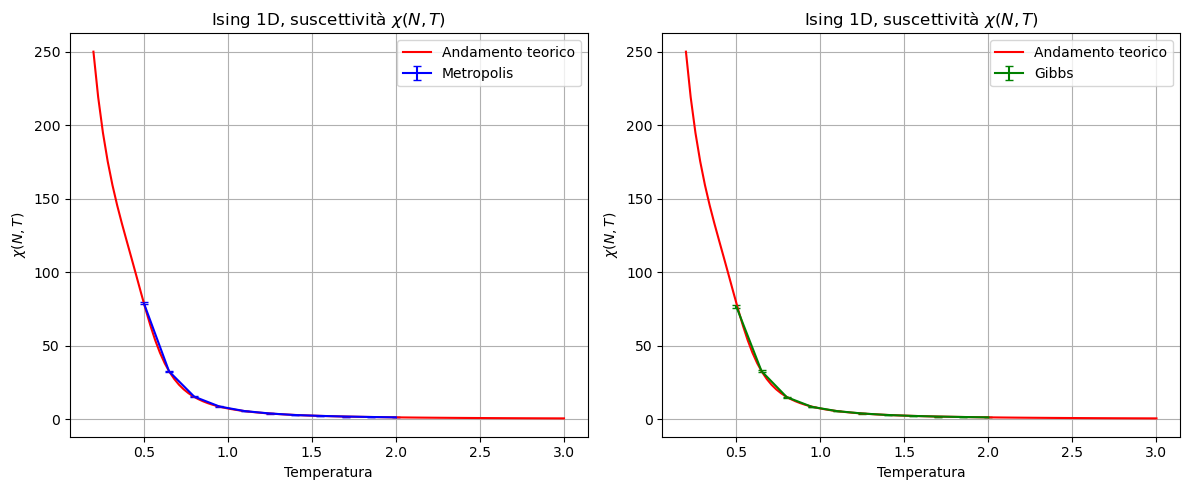

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data_chi_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/susceptibility.dat")
data_chi_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/susceptibility.dat")

temperature = data_chi_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

chi_m = data_chi_m[:,3] # carico i valori medi 
error_chi_m = data_chi_m[:,4]

chi_g = data_chi_g[:,3] # carico i valori medi 
error_chi_g = data_chi_g[:,4]

#linea teorica
points=100
T = np.linspace(0.2,3.0,num=points)
beta = 1/T
J = 1.0
Ns = 50
th = np.tanh(J/T)
thN= th**Ns
X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, chi_m, yerr=error_chi_m, color = 'b', capsize=3 , label='Metropolis')
axes[0].plot(T, X, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$\chi(N,T)$")
axes[0].set_title("Ising 1D, suscettività $\chi(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, chi_g, yerr=error_chi_g, color = 'g', capsize=3 , label='Gibbs')
axes[1].plot(T, X, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$\chi(N,T)$")
axes[1].set_title("Ising 1D, suscettività $\chi(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()




**4) Magnetizzazione $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$**

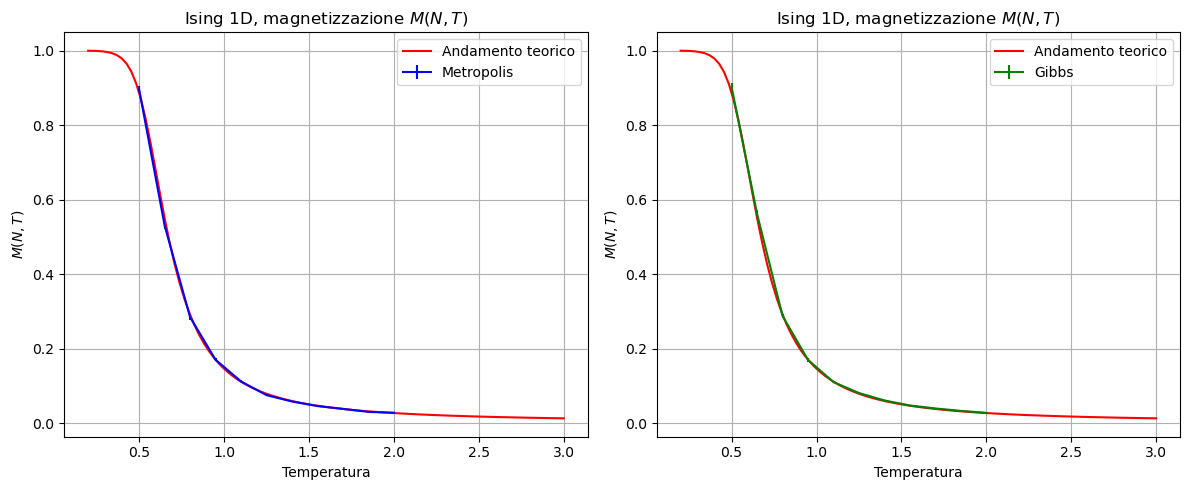

In [32]:
import numpy as np
import matplotlib.pyplot as plt

data_mag_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/magnetization.dat")
data_mag_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/magnetization.dat")

temperature = data_mag_m[:,0] # le temperature a cui sono state effettuate le varie simulazioni sono sempre le stesse

mag_m = data_mag_m[:,3] # carico i valori medi 
error_mag_m = data_mag_m[:,4]

mag_g = data_mag_g[:,3] # carico i valori medi 
error_mag_g = data_mag_g[:,4]

#linea teorica
h=0.02 #external field
b = 1/T

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 riga, 2 colonne

axes[0].errorbar(temperature, mag_m, yerr=error_mag_m, color = 'b', label='Metropolis')
axes[0].plot(T, M, color = 'r', label='Andamento teorico' )
axes[0].set_xlabel("Temperatura")
axes[0].set_ylabel("$M(N,T)$")
axes[0].set_title("Ising 1D, magnetizzazione $M(N,T)$")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(temperature, mag_g, yerr=error_mag_g, color = 'g', label='Gibbs')
axes[1].plot(T, M, color = 'r', label='Andamento teorico' )
axes[1].set_xlabel("Temperatura")
axes[1].set_ylabel("$M(N,T)$")
axes[1].set_title("Ising 1D, magnetizzazione $M(N,T)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


Commento sull'accettazione:

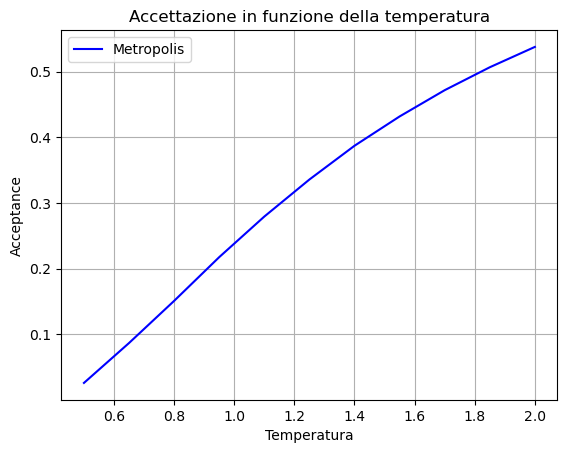

In [37]:
import numpy as np
import matplotlib.pyplot as plt

data_m = np.loadtxt("06.1/simulazioni-eseguite/metropolis/acceptance.dat")
#data_g = np.loadtxt("06.1/simulazioni-eseguite/gibbs/acceptance.dat")

T = data_m[:,0] 
acc_m = data_m[:,1] 
#acc_g = data_g[:,1] 

plt.plot(T, acc_m, color = 'b', label = 'Metropolis')
plt.xlabel("Temperatura")
plt.ylabel("Acceptance")
plt.title("Accettazione in funzione della temperatura")
plt.grid(True)
plt.legend()
plt.show()
